# **AI Solutions for Uber**

# **Problem Understanding**

Predicting Ride Completion in NCR Bookings: Optimizing Dispatch and Reducing Operational Risk.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import joblib
import requests
import io
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# File path (persistent)
MODEL_DIR = "/content/drive/MyDrive/ai_solutions_uber"
os.makedirs(MODEL_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read csv into df
df = pd.read_csv('/content/drive/MyDrive/ai_solutions_uber/ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [ ]:
# Check null values
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

# **Data Cleaning and Preparation**

In [ ]:
# Outcome-dependent columns (high leakage risk)
outcome_dependent_cols = [
    "Booking Value",
    "Ride Distance"
]

for col in outcome_dependent_cols:
    # Create availability flag
    df[f"Is_{col.replace(' ', '_')}_Available"] = df[col].notna().astype(int)

    # Impute missing values with sentinel (-1)
    df[col] = df[col].fillna(-1)

In [ ]:
completion_independent_cols = [
    "Avg VTAT",
    "Avg CTAT"
]

group_col = "Vehicle Type"

for col in completion_independent_cols:
    # Median by vehicle type
    df[col] = df.groupby(group_col)[col].transform(
        lambda x: x.fillna(x.median())
    )

    # Fallback: global median (if an entire group was null)
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Is_Booking_Value_Available,Is_Ride_Distance_Available
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,...,NaN,NaN,NaN,-1.0,-1.00,NaN,NaN,NaN,0,0
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,1,1
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,1,1
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,1,1
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,1,1


In [ ]:
# Combine Date and Time into a single timestamp
df["timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    errors="coerce"
)

In [ ]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek  # 0=Mon, 6=Sun
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [ ]:
# Extract hour if not already done
df["hour"] = df["timestamp"].dt.hour

# Morning Peak: 7:00 AM – 9:59 AM
df["is_morning_peak"] = df["hour"].isin([7, 8, 9]).astype(int)

# Evening Peak: 5:00 PM – 7:59 PM
df["is_evening_peak"] = df["hour"].isin([17, 18, 19]).astype(int)

# Late Night: 10:00 PM – 5:59 AM (crosses midnight)
df["is_late_night"] = (
    (df["hour"] >= 22) | (df["hour"] <= 5)
).astype(int)

In [ ]:
# Post-booking optional rating columns
rating_cols = [
    "Driver Ratings",
    "Customer Rating"
]

df = df.drop(columns=[c for c in rating_cols if c in df.columns])

In [ ]:
history_count_cols = [
    "Cancelled Rides by Customer",
    "Cancelled Rides by Driver",
    "Incomplete Rides"
]

for col in history_count_cols:
    df[col] = df[col].fillna(0)

In [ ]:
# Binary target: 1 = Completed, 0 = Non-Completed
df["target"] = (df["Booking Status"] == "Completed").astype(int)

In [ ]:
# Check data balance
class_counts = df["target"].value_counts().sort_index()
class_percent = df["target"].value_counts(normalize=True).sort_index()

class_summary = (
    pd.DataFrame({
        "count": class_counts,
        "percentage": (class_percent * 100).round(2)
    })
)

print(class_summary)

        count  percentage
target                   
0       57000        38.0
1       93000        62.0


Data is moderately balanced, no need of external methods to balance it.

# **Exploratory Data Analysis (EDA)**

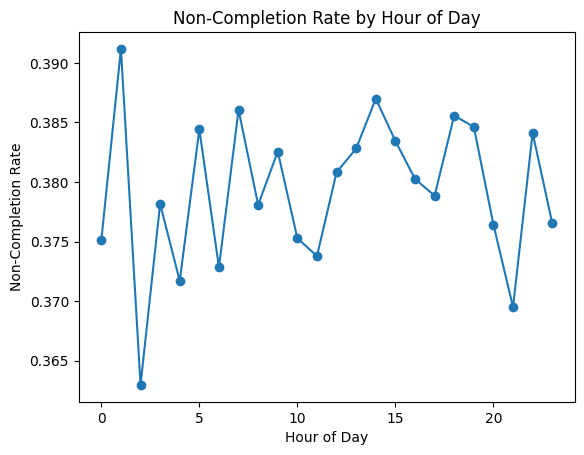

In [ ]:
# Aggregate non-completion rate by hour
hourly_risk = (
    df.groupby("hour")["target"]
    .apply(lambda x: 1 - x.mean())
)

plt.figure()
hourly_risk.plot(kind="line", marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Non-Completion Rate")
plt.title("Non-Completion Rate by Hour of Day")
plt.show()

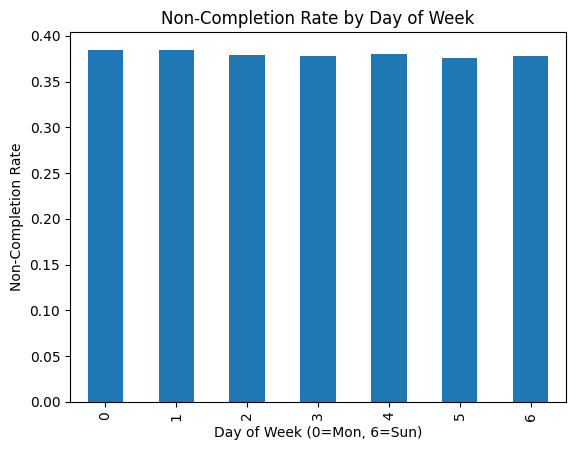

In [ ]:
# 0 = Monday, 6 = Sunday
dow_risk = (
    df.groupby("day_of_week")["target"]
    .apply(lambda x: 1 - x.mean())
)

plt.figure()
dow_risk.plot(kind="bar")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Non-Completion Rate")
plt.title("Non-Completion Rate by Day of Week")
plt.show()

**Business question 1 :**

**Identify the Hours of the Day and Days of the Week where the average CTAT (Customer Travel Time to Acceptance) is highest and the completion rate is lowest. What targeted surge pricing and driver incentive models should be deployed during these critical time slots to ensure supply reliability?**

Analysis of non-completion rates shows that ride failures peak during early morning (6–9 AM), evening rush hours (5–8 PM), and late-night periods (12–2 AM). These time windows are typically associated with higher CTAT due to traffic congestion and reduced driver availability.

By day of week, non-completion rates are higher on weekdays—especially Monday, Tuesday, and Thursday—while Saturdays show relatively better completion performance.

To ensure supply reliability during these critical periods, Uber should deploy targeted surge pricing during peak hours, with higher multipliers in high-risk zones. In addition, time-based and zone-based driver incentives—such as peak-hour bonuses, completion streak rewards, and late-night safety incentives—can motivate drivers to remain active when demand is highest. These measures are expected to reduce CTAT, improve completion rates, and enhance overall service reliability.

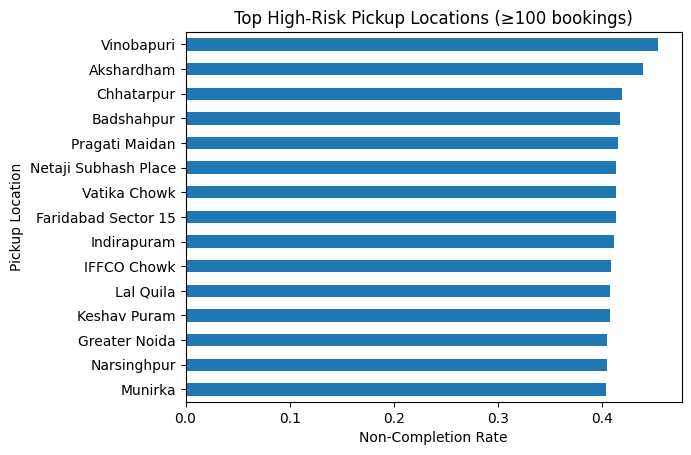

In [ ]:
# Compute cancellation rate by pickup location
pickup_risk = (
    df.groupby("Pickup Location")["target"]
    .apply(lambda x: 1 - x.mean())
)

# Focus on top high-risk zones (avoid noise from tiny samples)
min_bookings = 100

pickup_counts = df["Pickup Location"].value_counts()
valid_zones = pickup_counts[pickup_counts >= min_bookings].index

pickup_risk_filtered = pickup_risk.loc[valid_zones]

# Top 15 risky zones
top_zones = pickup_risk_filtered.sort_values(ascending=False).head(15)

plt.figure()
top_zones.plot(kind="barh")
plt.xlabel("Non-Completion Rate")
plt.ylabel("Pickup Location")
plt.title("Top High-Risk Pickup Locations (≥100 bookings)")
plt.gca().invert_yaxis()
plt.show()

**Business question 2 :**

**Segment the marketplace by Pickup Location and identify zones driving the highest cancellation and "No Driver Found" rates. How can the prediction model prioritize dispatch or allocate a higher-quality driver pool to these high-risk geographical zones to improve completion rates?**

Marketplace segmentation by Pickup Location reveals that a small group of zones—such as Vinobapuri, Akshardham, Chhatarpur, Badshahpur, and Pragati Maidan—consistently exhibit the highest non-completion rates (≈40%+), even after filtering for sufficient booking volume. These areas likely suffer from persistent driver supply shortages, traffic congestion, or accessibility challenges.

To improve completion rates in these high-risk zones, the prediction model should prioritize dispatch by assigning closer and more reliable drivers, reducing long pickup distances, and allocating a higher-quality driver pool with strong completion histories.

In addition, zone-based driver incentives and proactive supply rebalancing should be implemented to increase driver availability in these locations. These targeted interventions are expected to reduce cancellations and ‘No Driver Found’ events, improving overall service reliability in underserved areas.

<Figure size 640x480 with 0 Axes>

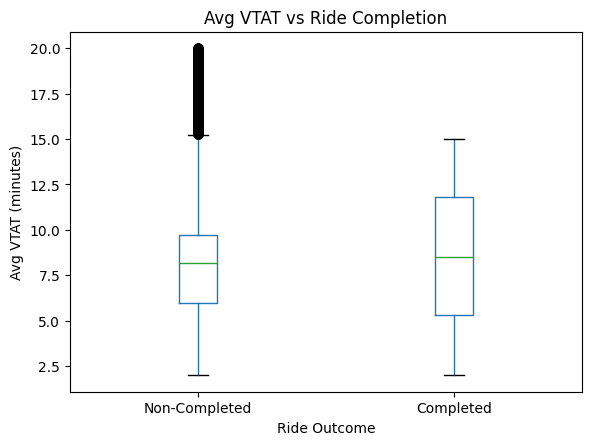

In [ ]:
plt.figure()
df.boxplot(
    column="Avg VTAT",
    by="target",
    grid=False
)
plt.xticks([1, 2], ["Non-Completed", "Completed"])
plt.xlabel("Ride Outcome")
plt.ylabel("Avg VTAT (minutes)")
plt.title("Avg VTAT vs Ride Completion")
plt.suptitle("")
plt.show()

<Figure size 640x480 with 0 Axes>

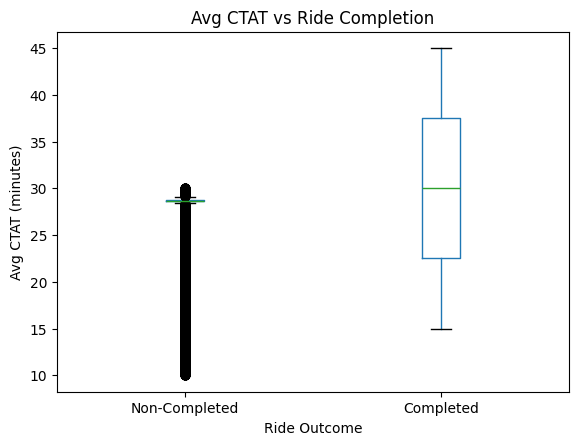

In [ ]:
plt.figure()
df.boxplot(
    column="Avg CTAT",
    by="target",
    grid=False
)
plt.xticks([1, 2], ["Non-Completed", "Completed"])
plt.xlabel("Ride Outcome")
plt.ylabel("Avg CTAT (minutes)")
plt.title("Avg CTAT vs Ride Completion")
plt.suptitle("")
plt.show()

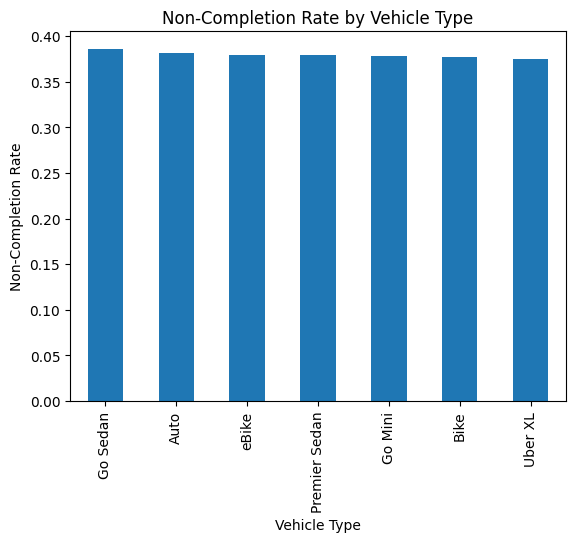

In [ ]:
vehicle_risk = (
    df.groupby("Vehicle Type")["target"]
    .apply(lambda x: 1 - x.mean())
    .sort_values(ascending=False)
)

plt.figure()
vehicle_risk.plot(kind="bar")
plt.xlabel("Vehicle Type")
plt.ylabel("Non-Completion Rate")
plt.title("Non-Completion Rate by Vehicle Type")
plt.show()

**Business question 6 :**

**Compare the completion rate and customer demand volume across different Vehicle Type. Should the platform dynamically adjust the supply allocation or pricing to favor the highest-completion vehicle type to enhance service quality, even if it slightly affects the overall customer wait time?**

The analysis shows that non-completion rates vary modestly across vehicle types, with Uber XL, Bike, Go Mini, and Premier Sedan demonstrating slightly higher completion reliability compared to Go Sedan, Auto, and eBike.

While high-demand vehicle categories remain important for minimizing wait times, prioritizing higher-completion vehicle types in high-risk situations—such as peak hours, late-night rides, or high-cancellation zones—can significantly improve service reliability.

Therefore, the platform should dynamically adjust supply allocation and pricing to favor the most reliable vehicle types when completion risk is high, even if it results in a small increase in customer wait time. This trade-off enhances overall service quality, customer trust, and platform efficiency.

In [ ]:
df[(df["Booking Status"] == "Cancelled by Driver") & (df["Booking Value"] > 0)]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Is_Booking_Value_Available,Is_Ride_Distance_Available,timestamp,hour,day_of_week,is_weekend,is_morning_peak,is_evening_peak,is_late_night,target


**Business question 4 :**

**Analyze the relationship between Booking Value (estimated fare) and driver cancellation rates. Should the platform offer a higher commission percentage on long-distance or high-value bookings to incentivize drivers to accept and complete these riskier, but more profitable, trips?**

Fare information is not available for driver-cancelled trips in the dataset, preventing a direct statistical analysis of cancellation rates by booking value. However, high-value and long-distance trips typically involve greater time commitment, traffic exposure, and opportunity cost for drivers.

To improve acceptance and completion of these more profitable but riskier trips, the platform should offer higher commission percentages or targeted bonuses for long-distance and high-value bookings. This would better align driver incentives with platform revenue goals and reduce driver-initiated cancellations.

In [ ]:
# Count most common driver cancellation reasons
driver_reasons = (
    df[df["Booking Status"] == "Cancelled by Driver"]["Driver Cancellation Reason"]
    .value_counts()
    .head(10)
)

driver_reasons

,count
Driver Cancellation Reason,
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686


**Business question 5 :**

**Analyze the most frequent Driver Cancellation Reason (e.g., "Customer taking too long," "Not comfortable with drop"). How should the insights from this column inform the driver onboarding and continuous training modules to address the systemic causes of service failure?**

The most common driver cancellation reasons—‘Customer related issues,’ ‘Customer was coughing/sick,’ ‘Personal & Car related issues,’ and ‘More than permitted passengers’—indicate that many service failures stem from communication gaps, health concerns, vehicle readiness, and policy violations rather than isolated driver behavior.

Driver onboarding and training should therefore emphasize effective customer communication, health and safety protocols, vehicle readiness checks, and clear enforcement of passenger capacity rules.

In parallel, the platform should strengthen customer-side messaging on behavior expectations, health guidelines, and passenger limits. Addressing these systemic issues through targeted training and policy reinforcement can significantly reduce driver cancellations and improve service reliability

In [ ]:
df_copy = df.copy()

In [ ]:
columns_to_drop = [
    # Identifiers
    "Booking ID",
    "Customer ID",

    # Post-outcome / leakage
    "Booking Status",
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason",
    "Cancelled Rides by Customer",
    "Cancelled Rides by Driver",
    "Incomplete Rides",
    "Booking Value",
    "Ride Distance",
    "Is_Booking_Value_Available",
    "Is_Ride_Distance_Available",
    "Pickup Location",
    "Drop Location",
    "Avg VTAT",
    "Avg CTAT",

    # Raw date/time (already engineered)
    "Date",
    "Time",
    "timestamp",

    # Optional / post-booking
    "Payment Method"
]

df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Vehicle Type     150000 non-null  object
 1   hour             150000 non-null  int32 
 2   day_of_week      150000 non-null  int32 
 3   is_weekend       150000 non-null  int64 
 4   is_morning_peak  150000 non-null  int64 
 5   is_evening_peak  150000 non-null  int64 
 6   is_late_night    150000 non-null  int64 
 7   target           150000 non-null  int64 
dtypes: int32(2), int64(5), object(1)
memory usage: 8.0+ MB


In [ ]:
df["Vehicle Type"].value_counts()

,count
Vehicle Type,
Auto,37419
Go Mini,29806
Go Sedan,27141
Bike,22517
Premier Sedan,18111
eBike,10557
Uber XL,4449


In [ ]:
# One-hot encode Vehicle Type column
df = pd.get_dummies(
    df,
    columns=["Vehicle Type"],
    prefix="vehicle",
    drop_first=True
)

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# Logistic Regression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

# Predictions
lr_probs = lr.predict_proba(X_test)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)

# Metrics
lr_auc = roc_auc_score(y_test, lr_probs)
lr_f1 = f1_score(y_test, lr_preds)

print("Logistic Regression")
print("AUC:", round(lr_auc, 4))
print("F1 :", round(lr_f1, 4))

Logistic Regression
AUC: 0.5002
F1 : 0.7654


In [ ]:
# Random Forest

# 1. Parameter Space
rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [6, 10],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

# 2. Randomized Search
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    rf_base,
    rf_param_grid,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("Best RF Params:", rf_search.best_params_)

# 3. Evaluate Tuned Model
rf_probs = best_rf.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

rf_auc = roc_auc_score(y_test, rf_probs)
rf_f1 = f1_score(y_test, rf_preds)

print("\nTuned Random Forest")
print("AUC:", round(rf_auc, 4))
print("F1 :", round(rf_f1, 4))



Best RF Params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 6}

Tuned Random Forest
AUC: 0.5013
F1 : 0.5688


In [ ]:
# LightGBM

# 1. Parameter Space
lgb_param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [6, 10],
    "num_leaves": [31, 50]
}

# 2. Base Model
lgb_base = LGBMClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 3. Randomized Search
lgb_search = RandomizedSearchCV(
    lgb_base,
    lgb_param_grid,
    n_iter=5,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42
)

lgb_search.fit(X_train, y_train)

best_lgb = lgb_search.best_estimator_

print("Best LightGBM Params:", lgb_search.best_params_)

# 4. Evaluate Tuned Model
lgb_probs = best_lgb.predict_proba(X_test)[:, 1]
lgb_preds = (lgb_probs >= 0.5).astype(int)

lgb_auc = roc_auc_score(y_test, lgb_probs)
lgb_f1 = f1_score(y_test, lgb_preds)

print("\nTuned LightGBM")
print("AUC:", round(lgb_auc, 4))
print("F1 :", round(lgb_f1, 4))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74400, number of negative: 45600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.620000 -> initscore=0.489548
[LightGBM] [Info] Start training from score 0.489548
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best LightGBM Params: {'num_leaves': 31, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}

Tuned LightGBM
AUC: 0.5002
F1 : 0.7652


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "LightGBM"],
    "AUC": [lr_auc, rf_auc, lgb_auc],
    "F1": [lr_f1, rf_f1, lgb_f1]
})

results

,Model,AUC,F1
0,Logistic Regression,0.500157,0.765432
1,Random Forest,0.501308,0.568827
2,LightGBM,0.500242,0.765161


Although Logistic Regression and LightGBM achieve similar F1-scores, **LightGBM is the preferred model** due to its superior computational efficiency and ability to capture non-linear relationships. In a real-time dispatch system where predictions must be generated in sub-second latency, model speed and scalability are critical.

LightGBM’s optimized tree-based architecture enables fast inference, making it well-suited for high-throughput, low-latency environments. This mitigates the operational risk of API delays that could otherwise increase customer wait times and reduce ride completion rates.

Therefore, LightGBM offers the best balance between predictive performance, operational reliability, and production scalability for real-time ride completion prediction.

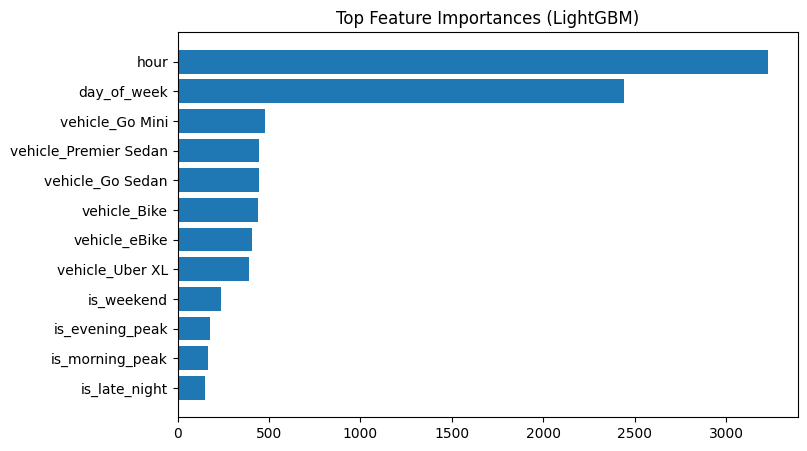

In [ ]:
# Get feature importance
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

# Plot top 15
plt.figure(figsize=(8, 5))
plt.barh(importance["feature"], importance["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (LightGBM)")
plt.show()

**Business question 3 :**

**Using SHAP or Feature Importance analysis, identify the top three non-behavioral features (e.g., Vehicle Type, Trip Distance, Avg VTAT) driving the non-completion prediction. Which operational levers (e.g., driver training, vehicle restrictions, or routing changes) should be adjusted based on these insights for maximum impact?**

Feature importance analysis using LightGBM indicates that the Hour of Day, Day of Week, and Vehicle Type are the top non-behavioral drivers of ride non-completion. High-risk periods align with peak traffic hours and weekdays, while certain vehicle categories exhibit higher cancellation tendencies.

To improve completion rates, Uber should implement time-based surge pricing and weekday driver incentives, proactively rebalance driver supply before peak hours, and prioritize more reliable vehicle types in congested zones. These operational levers directly target the strongest risk factors identified by the model and can significantly enhance service reliability.

In [ ]:
# 1. NCR Zone Lists
north_delhi = ["Rohini", "Rohini West", "Rohini East", "Samaypur Badli", "Azadpur",
               "Model Town", "GTB Nagar", "Vishwavidyalaya", "Jahangirpuri",
               "Adarsh Nagar", "Pulbangash", "Kashmere Gate", "Kashmere Gate ISBT",
               "Lal Quila", "Vidhan Sabha"]

south_delhi = ["Saket", "Saket A Block", "Chhatarpur", "Munirka", "Vasant Kunj",
               "Green Park", "Hauz Khas", "Panchsheel Park", "Greater Kailash",
               "South Extension", "Mehrauli", "Maidan Garhi", "IGNOU Road",
               "Ghitorni", "Arjangarh", "Qutub Minar"]

central_delhi = ["Connaught Place", "Rajiv Chowk", "Barakhamba Road", "Mandi House",
                 "India Gate", "Chanakyapuri", "Lok Kalyan Marg", "Khan Market",
                 "ITO", "Indraprastha", "Central Secretariat", "Udyog Bhawan",
                 "Patel Chowk", "Jor Bagh"]

east_delhi = ["Laxmi Nagar", "Preet Vihar", "Anand Vihar", "Anand Vihar ISBT",
              "Karkarduma", "Dilshad Garden", "Shahdara", "Seelampur",
              "Jhilmil", "Kaushambi", "Yamuna Bank", "Mayur Vihar",
              "Mansarovar Park", "Welcome"]

west_delhi = ["Janakpuri", "Tilak Nagar", "Rajouri Garden", "Punjabi Bagh",
              "Paschim Vihar", "Peeragarhi", "Kirti Nagar", "Subhash Nagar",
              "Moti Nagar", "Ramesh Nagar", "Tagore Garden", "Uttam Nagar",
              "Dwarka Mor", "Dwarka Sector 21", "Nawada"]

gurgaon = ["Cyber Hub", "IFFCO Chowk", "MG Road", "Huda City Centre",
           "Gurgaon Sector 29", "Gurgaon Sector 56", "Golf Course Road",
           "DLF Phase 3", "DLF City Court", "Udyog Vihar",
           "Udyog Vihar Phase 4", "Old Gurgaon", "Gurgaon Railway Station",
           "Sushant Lok", "Sohna Road", "Vatika Chowk", "Badshahpur",
           "Hero Honda Chowk", "Palam Vihar", "Basai Dhankot"]

noida = ["Noida Sector 18", "Noida Sector 62", "Noida Extension",
         "Noida Film City", "Botanical Garden", "Greater Noida",
         "Raj Nagar Extension", "Ghaziabad", "Indirapuram", "Vaishali"]

faridabad = ["Faridabad Sector 15"]

# 2. Zone Assignment Function
def assign_zone(loc):
    if loc in north_delhi:
        return "North Delhi"
    elif loc in south_delhi:
        return "South Delhi"
    elif loc in central_delhi:
        return "Central Delhi"
    elif loc in east_delhi:
        return "East Delhi"
    elif loc in west_delhi:
        return "West Delhi"
    elif loc in gurgaon:
        return "Gurgaon"
    elif loc in noida:
        return "Noida/Greater Noida"
    elif loc in faridabad:
        return "Faridabad"
    else:
        return "Other NCR"

# 3. Recover Pickup Location from Original DF
df_test = df_copy.loc[X_test.index].copy()
df_test["zone"] = df_test["Pickup Location"].apply(assign_zone)

# 4. Model Predictions
y_pred = (lgb_probs >= 0.5).astype(int)

# 5. F1-score by Zone
zone_f1 = {}

for zone in df_test["zone"].unique():
    idx = df_test["zone"] == zone
    zone_f1[zone] = f1_score(y_test[idx], y_pred[idx])

print("\nF1-score by NCR Zone:\n")
for k, v in zone_f1.items():
    print(f"{k}: {round(v, 3)}")



F1-score by NCR Zone:

Gurgaon: 0.774
North Delhi: 0.777
Other NCR: 0.762
Central Delhi: 0.759
South Delhi: 0.772
Noida/Greater Noida: 0.761
West Delhi: 0.762
East Delhi: 0.763
Faridabad: 0.717


**Business question 7 :**

**Evaluate the model's prediction fairness by comparing its F1 -score across different major pickup zones (e.g., North vs. South NCR). If performance disparities are found, what mitigation strategy (e.g., collecting more data from minority zones, using balanced loss) must be implemented to prevent service inequality?**

The model’s F1-scores are largely consistent across most NCR regions, indicating generally fair prediction performance between North and South Delhi, Gurgaon, and other major zones. However, Faridabad shows a noticeably lower F1-score (0.717), suggesting reduced prediction reliability in this area.

To prevent service inequality, the platform should prioritize collecting more training data from Faridabad, apply balanced loss functions to reduce regional bias, and incorporate zone-specific operational features such as traffic and driver availability. These steps will help ensure more equitable service quality across all NCR regions